# Part 8: Hierarchical/Mixed-Effect Model Inference

A type of model that is common in practice but tricky to implement are mixed-effect state space models, which allow individuals to posess their own parameters, derived from a local or global prior. These types of models are expressible in `dynestyx` using its `plate` primitive. In this tutorial, we implement a simple trajectory-level Ornstein-Uhlenbeck process, where each trajectory has a different mean.


## The Goal

One natural modeling choice that turns out to be somewhat difficult to implement is **hierarchical inference** for dynamical systems, sometimes called mixed-effect state space models. These may arise in a variety of settings, but one that's easy to imagine are in medical studies: parameters may be pooled at a global level via a prior $p(\theta_\text{global})$, but individual patients still posses their own distinct parameters, $\theta_i \sim p(\theta_\text{global})$. To further complicate things, there may be multiple levels of hierarchy -- for example, with heterogenous subpopulations.

Our goal in this tutorial is to write this type of hierarchical dynamical model; to do so, we introduce the final primitive of `dynestyx`, the `plate`. This plate functions a lot like a `numpyro.plate`, but includes some different implementation details to accomodate dynamical systems. Let's first refresh how plates work in NumPyro.

## Primer: Plates in NumPyro

Plates are a concept present generally in the Pyro family of probabilistic programming languages, and allow you to express conditional independence (a la a Bayesian plate diagram). Take for example the following 

$$
\begin{array}{lll}
    &\mu_{\text{global}} &\sim \mathcal{N}(0.0, 2.0^2) & \\ 
    &\mu_i \,|\, \mu_{\text{global}} &\stackrel{\mathrm{iid}}{\sim} \mathcal{N}(\mu_{\text{global}}, 0.5^2) \qquad &(i=1, \dots, N) \\
    &y_i \,|\, \mu_i &\sim \mathcal{N}(\mu_i, 0.1^2) \qquad &(i = 1, \dots, N).
\end{array}
$$

The way to write this model in NumPyro is with a `numpyro.plate` statement, which automatically vectorizes all quantities to the correct shape:

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist


def hierarchical_numpyro_model(ys=None, N=None):
    if ys is not None:
        if N is not None:
            assert len(ys) == N
        N = len(ys)

    mu_global = numpyro.sample("mu_global", dist.Normal(0.0, 0.5))
    with numpyro.plate("N", N):
        mu_i = numpyro.sample("mu_i", dist.Normal(mu_global, 0.5))
        numpyro.sample("y_i", dist.Normal(mu_i, 0.1), obs=ys)

This is consistent with all other NumPyro operations: we can generate data with `predictive`, or do inference with `NUTS`, etc.:

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_16879/406329702.py:23: SyntaxWarning: invalid escape sequence '\m'
  label="True $\mu_i$",
/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_16879/406329702.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu_i$")
sample: 100%|██████████| 2000/2000 [00:00<00:00, 4211.04it/s, 7 steps of size 6.05e-01. acc. prob=0.91]


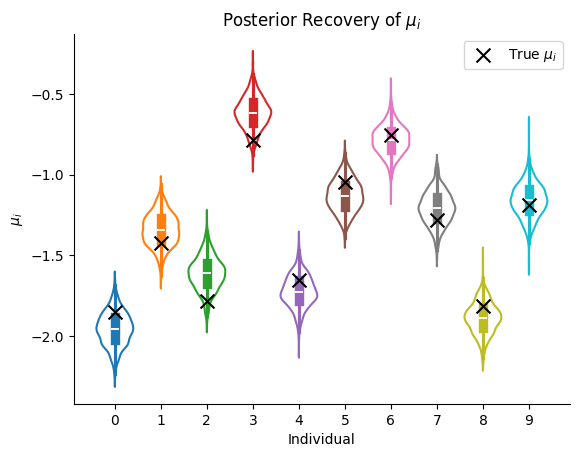

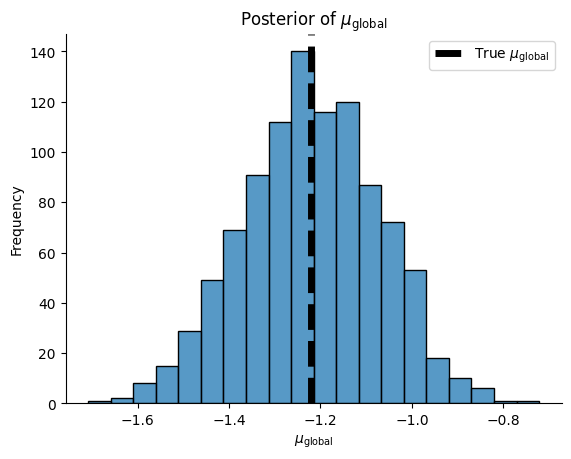

In [2]:
from numpyro.infer import NUTS, MCMC, Predictive
import seaborn as sns
import matplotlib.pyplot as plt

# Generate data with predictive
predictive = Predictive(hierarchical_numpyro_model, num_samples=1)
synthetic_data = predictive(jr.PRNGKey(0), N=10)

# Infer mu_i and mu_global with NUTS
nuts_kernel = NUTS(hierarchical_numpyro_model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000)
mcmc.run(jr.PRNGKey(0), ys=synthetic_data["y_i"].squeeze())

# Plot the posterior distribution of mu_i and mu_global
sns.violinplot(data=mcmc.get_samples()["mu_i"], fill=False)
plt.scatter(
    range(10),
    synthetic_data["mu_i"],
    color="black",
    zorder=10,
    marker="x",
    s=100,
    label="True $\mu_i$",
)
sns.despine()
plt.title(r"Posterior Recovery of $\mu_i$")
plt.xlabel("Individual")
plt.ylabel("$\mu_i$")
plt.legend()
plt.show()

# Plot the posterior of mu_global
sns.histplot(mcmc.get_samples()["mu_global"], bins=20)
plt.axvline(
    synthetic_data["mu_global"],
    color="black",
    linestyle="--",
    lw=5,
    label=r"True $\mu_{\text{global}}$",
)
plt.legend()
plt.title(r"Posterior of $\mu_{\text{global}}$")
plt.xlabel(r"$\mu_{\text{global}}$")
plt.ylabel("Frequency")
sns.despine()
plt.show()

## Plates in dynestyx

Dynestyx also supports this type of "hierarchical" inference --- also sometimes called mixed effect state space models. For a variety of reasons, `dynestyx` implements this feature as its own `plate` primitive. The `dynestyx.plate` inherits `numpyro.plate` behavior for `numpyro.sample` statements, with new, added features for `dsx.sample` statements. Let's look at an example, similar to the one above. We'll define a mean-reverting SDE for each individual trajectory, with independent means for each trajectory.

$$
\begin{array}{lll}
    &\mu_{\text{global}} &\sim \mathcal{N}(0.0, 2.0^2) & \\ 
    &\mu_i \,|\, \mu_{\text{global}} &\stackrel{\mathrm{iid}}{\sim} \mathcal{N}(\mu_{\text{global}}, 0.5^2) \qquad &(i=1, \dots, N) \\
    &dx_i &= - 0.5 (x_i - \mu_i) dt + d\beta_t \qquad &(i = 1, \dots, N) \\
    &{y_i}_{t_k} &= {x_i}_{t_k} + \varepsilon_{i, k} \qquad & (i = 1, \dots, N; k = 1, \dots, K),
\end{array}
$$

where $\varepsilon_{i, k}$ is i.i.d. Gaussian noise with variance $0.5^2$.

To implement this model in `dynestyx`, we use a `dynestyx.plate` statement. The key is that all of our callable functions (drift, diffusion) should be batch-compatible (and vmapped, if necessary). For this to work, we should wrap all callable functions in an `Equinox` module.

In [3]:
import dynestyx as dsx
from dynestyx import (
    DynamicalModel,
    ContinuousTimeStateEvolution,
    LinearGaussianObservation,
    Simulator,
)
import jax
import equinox as eqx
from dynestyx import Filter
from dynestyx.inference.filters import ContinuousTimeEnKFConfig


class OUDrift(eqx.Module):
    mu_i: jnp.ndarray

    def __call__(self, x, u, t):
        return -0.5 * (x - self.mu_i)


class ConstantDiffusion(eqx.Module):
    sigma: jnp.ndarray
    state_dim: int

    def __call__(self, x, u, t):
        return jnp.ones((self.state_dim,)) * self.sigma


def hierarchical_dynamic_model(
    obs_times=None, obs_values=None, predict_times=None, N_trajectories=None
):
    assert N_trajectories is not None, "N must be specified"
    mu_global = numpyro.sample("mu_global", dist.Normal(0.0, 0.5))

    with dsx.plate("N", N_trajectories):
        # Under a dsx.plate statement, `numpyro.sample` statements are
        # treated just like under a `numpyro.plate` statement.
        mu_i = numpyro.sample("mu_i", dist.Normal(mu_global, 1.0))

        # We implement the ContinuousTimeStateEvolution with equinox modules
        # for the drift and diffusion, and make sure they're both batch-compatible.
        state_evolution = ContinuousTimeStateEvolution(
            drift=OUDrift(mu_i),  # eqx.Module
            diffusion_coefficient=ConstantDiffusion(0.1, state_dim=1),  # eqx.Module
            bm_dim=1,
        )

        # We now define the DynamicalModel, which uses a single initial_condition.
        dynamical_model = DynamicalModel(
            initial_condition=dist.MultivariateNormal(
                jnp.zeros(1), 0.5 * jnp.eye(1)
            ),  # shared initial condition
            state_evolution=state_evolution,
            observation_model=LinearGaussianObservation(
                H=jnp.array([[1.0]]),
                R=jnp.array([[0.1**2]]),
            ),  # linear Gaussian observations are already compatible with batching
        )

        # Finally, we sample **inside** the plate.
        return dsx.sample(
            "f",
            dynamical_model,
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=predict_times,
        )

We can then generate data, again, using the same type of interface!

In [4]:
predict_times = jnp.linspace(0.0, 10.0, 100)

with Simulator():
    predictive = Predictive(hierarchical_dynamic_model, num_samples=1)
    synthetic_data = predictive(
        jr.PRNGKey(0), N_trajectories=10, predict_times=predict_times
    )

We now have data from 10 trajectories, drawn from 10 different $\mu_i$ values:

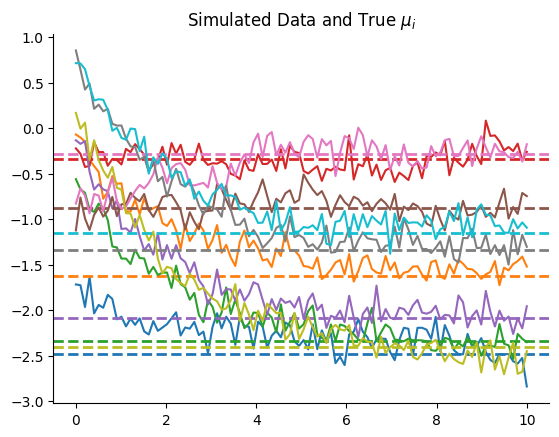

In [5]:
for i in range(10):
    color = f"C{i}"
    plt.axhline(synthetic_data["mu_i"][0, i], color=color, linestyle="--", lw=2)
    # f_observation shape: (num_samples, n_trajectories, n_simulations, n_times, state_dim)
    #                    = (          1,             10,             1,     100,         1)
    plt.plot(
        predict_times, synthetic_data["f_observations"][0, i, 0, :, 0], color=color
    )

sns.despine()
plt.title(r"Simulated Data and True $\mu_i$")
plt.show()

Like in the NumPyro case, we can check that the parameters are recovered well in MCMC.

In [6]:
with Filter(ContinuousTimeEnKFConfig(warn=False, diffeqsolve_dt0=0.05)):
    mcmc = MCMC(NUTS(hierarchical_dynamic_model), num_warmup=100, num_samples=100)
    mcmc.run(
        jr.PRNGKey(0),
        N_trajectories=10,
        obs_times=synthetic_data["f_times"][0, :, 0],
        obs_values=synthetic_data["f_observations"][0, :, 0],
    )

/Users/danwaxman/Documents/dynestyx/dynestyx/inference/integrations/cd_dynamax/utils.py:127: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return _CallableFunction(fn=value)
sample: 100%|██████████| 200/200 [01:50<00:00,  1.81it/s, 7 steps of size 4.82e-01. acc. prob=0.94]


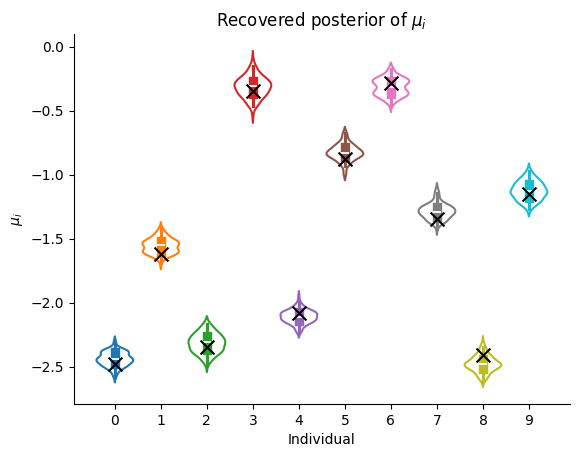

In [7]:
# Plot the posterior distribution of mu_i and mu_global
sns.violinplot(data=mcmc.get_samples()["mu_i"], fill=False)
plt.scatter(
    range(10),
    synthetic_data["mu_i"],
    color="black",
    zorder=10,
    marker="x",
    s=100,
    label=r"True $\mu_i$",
)
plt.title(r"Recovered posterior of $\mu_i$")
plt.xlabel(r"Individual")
plt.ylabel(r"$\mu_i$")
sns.despine()
plt.show()

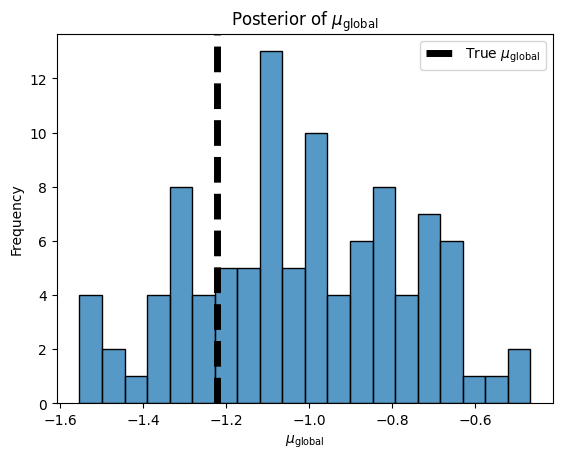

In [8]:
# Plot the posterior of mu_global
sns.histplot(mcmc.get_samples()["mu_global"], bins=20)
plt.axvline(
    synthetic_data["mu_global"],
    color="black",
    linestyle="--",
    lw=5,
    label=r"True $\mu_{\text{global}}$",
)
plt.legend()
plt.title(r"Posterior of $\mu_{\text{global}}$")
plt.xlabel(r"$\mu_{\text{global}}$")
plt.ylabel("Frequency")
plt.show()

## A Two-Layer Example

By stacking `dynestyx.plate` environments, we can capture **multiple levels** of hierarchy (for example, global prior -> local prior -> individual). The resulting code will look quite similar, by design!

In [9]:
def two_layer_hierarchical_model(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    N_groups=3,
    N_per_group=3,
):
    assert N_groups is not None, "N_grups must be specified"
    assert N_per_group is not None, "N_per_group must be specified"
    mu_global = numpyro.sample("mu_global", dist.Normal(0.0, 0.5))

    with dsx.plate("N_groups", N_groups):
        mu_group = numpyro.sample("mu_group", dist.Normal(mu_global, 2.0))
        with dsx.plate("N_per_group", N_per_group):
            # Under a dsx.plate statement, `numpyro.sample` statements are
            # treated just like under a `numpyro.plate` statement.
            mu_i = numpyro.sample("mu_i", dist.Normal(mu_group, 0.2))

            # We implement the ContinuousTimeStateEvolution with equinox modules
            # for the drift and diffusion, and make sure they're both batch-compatible.
            state_evolution = ContinuousTimeStateEvolution(
                drift=OUDrift(mu_i),  # eqx.Module
                diffusion_coefficient=ConstantDiffusion(0.1, state_dim=1),  # eqx.Module
                bm_dim=1,
            )

            # We now define the DynamicalModel, which uses a single initial_condition.
            dynamical_model = DynamicalModel(
                initial_condition=dist.MultivariateNormal(
                    jnp.zeros(1), 0.5 * jnp.eye(1)
                ),  # shared initial condition
                state_evolution=state_evolution,
                observation_model=LinearGaussianObservation(
                    H=jnp.array([[1.0]]),
                    R=jnp.array([[0.1**2]]),
                ),  # linear Gaussian observations are already compatible with batching
            )

            # Finally, we sample **inside** the plate.
            return dsx.sample(
                "f",
                dynamical_model,
                obs_times=obs_times,
                obs_values=obs_values,
                predict_times=predict_times,
            )

Simulation is exactly as before!

In [10]:
predict_times = jnp.linspace(0.0, 10.0, 100)

with Simulator():
    predictive = Predictive(two_layer_hierarchical_model, num_samples=1)
    synthetic_data = predictive(
        jr.PRNGKey(42), N_groups=3, N_per_group=3, predict_times=predict_times
    )

So is plotting, except that now we have an extra batch dimension...

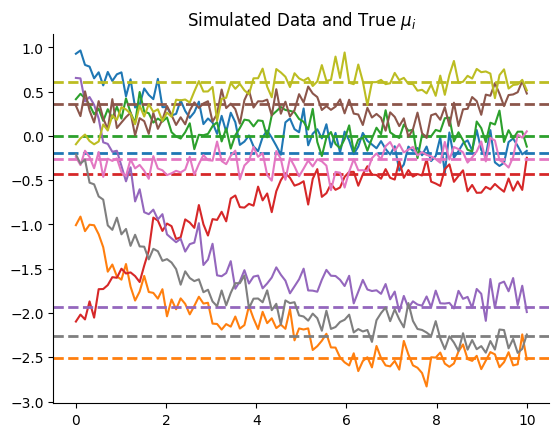

In [11]:
for i in range(3):
    for j in range(3):
        color = f"C{3 * i + j}"
        plt.axhline(synthetic_data["mu_i"][0, i, j], color=color, linestyle="--", lw=2)
        # f_observation shape: (num_samples, n_groups, n_per_group, n_simulations, n_times, state_dim)
        #                    = (          1,       3,             3,            1,     100,         1)
        plt.plot(
            predict_times,
            synthetic_data["f_observations"][0, i, j, 0, :, 0],
            color=color,
        )

sns.despine()
plt.title(r"Simulated Data and True $\mu_i$")
plt.show()

Now, we perform inference. Again, this looks the same as in the one-layer model.

In [12]:
with Filter(ContinuousTimeEnKFConfig(warn=False, diffeqsolve_dt0=0.05)):
    mcmc = MCMC(NUTS(two_layer_hierarchical_model), num_warmup=100, num_samples=100)
    mcmc.run(
        jr.PRNGKey(0),
        N_groups=3,
        N_per_group=3,
        obs_times=synthetic_data["f_times"][0, :, :, 0],
        obs_values=synthetic_data["f_observations"][0, :, :, 0],
    )

/Users/danwaxman/Documents/dynestyx/dynestyx/inference/integrations/cd_dynamax/utils.py:127: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return _CallableFunction(fn=value)
sample: 100%|██████████| 200/200 [02:11<00:00,  1.52it/s, 7 steps of size 7.08e-01. acc. prob=0.80] 


Now, we should check that **not only $\mu_i$ values are captured well, but so are $\mu_{\text{group}}$ values**.

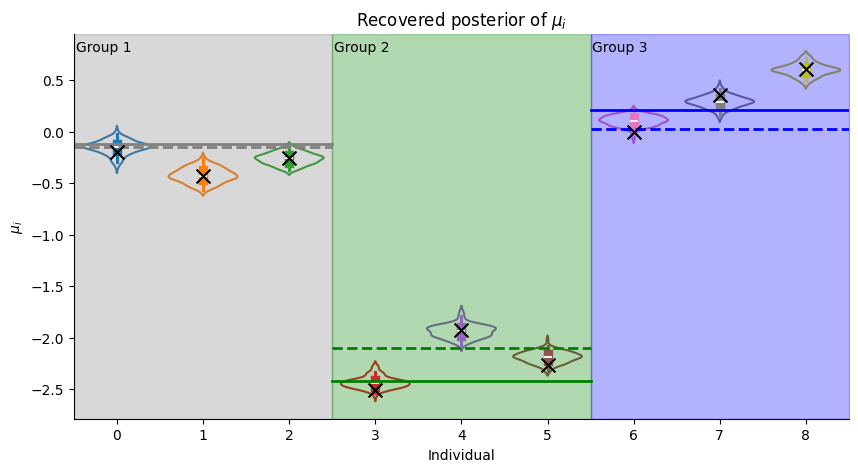

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the posterior distribution of mu_i and mu_global
sns.violinplot(
    data=mcmc.get_samples()["mu_i"].reshape(100, -1, order="F"), fill=False, ax=ax
)
ax.scatter(
    range(9),
    synthetic_data["mu_i"].reshape(-1, order="F"),
    color="black",
    zorder=10,
    marker="x",
    s=100,
    label=r"True $\mu_i$",
)

# Shade in each group
y_min, y_max = ax.get_ylim()
ax.fill_between([-0.5, 2.5], [y_min, y_min], [y_max, y_max], color="gray", alpha=0.3)
ax.fill_between([2.5, 5.5], [y_min, y_min], [y_max, y_max], color="green", alpha=0.3)
ax.fill_between([5.5, 8.5], [y_min, y_min], [y_max, y_max], color="blue", alpha=0.3)

# Label each group
ax.text(-0.5 + 0.02, y_max - 0.2, "Group 1", ha="left", va="bottom")
ax.text(2.5 + 0.02, y_max - 0.2, "Group 2", ha="left", va="bottom")
ax.text(5.5 + 0.02, y_max - 0.2, "Group 3", ha="left", va="bottom")

# Draw each group's posterior mean
ax.plot(
    [-0.5, 2.5],
    [mcmc.get_samples()["mu_group"][0, 0], mcmc.get_samples()["mu_group"][0, 0]],
    color="gray",
    linestyle="--",
    lw=2,
)
ax.plot(
    [2.5, 5.5],
    [mcmc.get_samples()["mu_group"][0, 1], mcmc.get_samples()["mu_group"][0, 1]],
    color="green",
    linestyle="--",
    lw=2,
)
ax.plot(
    [5.5, 8.5],
    [mcmc.get_samples()["mu_group"][0, 2], mcmc.get_samples()["mu_group"][0, 2]],
    color="blue",
    linestyle="--",
    lw=2,
)

# Draw each group's true mean
ax.plot(
    [-0.5, 2.5],
    [synthetic_data["mu_group"][0, 0], synthetic_data["mu_group"][0, 0]],
    color="gray",
    lw=2,
)
ax.plot(
    [2.5, 5.5],
    [synthetic_data["mu_group"][0, 1], synthetic_data["mu_group"][0, 1]],
    color="green",
    lw=2,
)
ax.plot(
    [5.5, 8.5],
    [synthetic_data["mu_group"][0, 2], synthetic_data["mu_group"][0, 2]],
    color="blue",
    lw=2,
)

# Reset axes
ax.set_ylim(y_min, y_max)
ax.set_xlim(-0.5, 8.5)

# Create legend
plt.plot([], [], linestyle="--", lw=2, label="Posterior Group Mean")
plt.plot([], [], lw=2, label="True Group Mean")

plt.title(r"Recovered posterior of $\mu_i$")
plt.xlabel(r"Individual")
plt.ylabel(r"$\mu_i$")
sns.despine()
plt.show()

We can again quantify the uncertainty in $\mu_{\text{global}}$ and each $\mu_{\text{group}}$ as well:

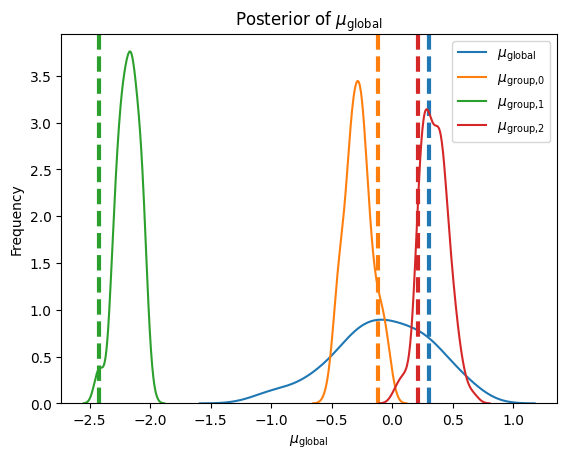

In [14]:
# Plot the posterior of mu_global
sns.kdeplot(mcmc.get_samples()["mu_global"], color="C0", label=r"$\mu_{\text{global}}$")
plt.axvline(
    synthetic_data["mu_global"],
    color="C0",
    linestyle="--",
    lw=3,
)

for i in range(3):
    sns.kdeplot(
        mcmc.get_samples()["mu_group"][:, i],
        color=f"C{i + 1}",
        label=rf"$\mu_\text{{group,{i}}}$",
    )
    plt.axvline(
        synthetic_data["mu_group"][0, i],
        color=f"C{i + 1}",
        linestyle="--",
        lw=3,
    )


plt.legend()
plt.title(r"Posterior of $\mu_{\text{global}}$")
plt.xlabel(r"$\mu_{\text{global}}$")
plt.ylabel("Frequency")
plt.show()